# Технологии программирования, БИ

## НИУ ВШЭ, 2025-26 учебный год

# Семинар 5. Docker

### Цели семинара

1. Вспомнить основную идею и мотивацию Docker.
2. Познакомиться с типовой средой разработчика через GitHub Codespaces и вспомнить материалы прошлых семинаров.
3. Осознать сущность образа.
4. Осознать сущность контейнера.
5. Создать и запустить первые контейнеры с авторской бизнес-логикой.
6. Выполнить мини-проект и выложить результат в открытый доступ.

> *Открываем ноутбук в Google Colab*

### Дополнительно:

1. [Документация](https://docs.docker.com/)
2. [Статья на Хабре](https://habr.com/ru/articles/310460/)
3. [Очень подробный курс](https://karpov.courses/docker)

# Вводное

## Назначение и базовая идея

Docker — это платформа для запуска приложений в изолированных окружениях, называемых контейнерами.

Контейнер позволяет упаковать приложение вместе с его зависимостями, системными библиотеками и настройками окружения. Это снижает различия между локальной разработкой, тестированием и запуском на сервере.

Docker используется для:
- воспроизводимого запуска приложений
- изоляции окружения
- упрощения поставки и развертывания
- стандартизации среды выполнения

Ниже размещается схема, показывающая основную Docker архитектуру, на эту схему крайне рекомендуется посмотреть **минимум три раза** для более глубокого понимания:
1) самый первый раз во время семинара
2) после того как выложат материал
3) после того, как сделаете ДЗ

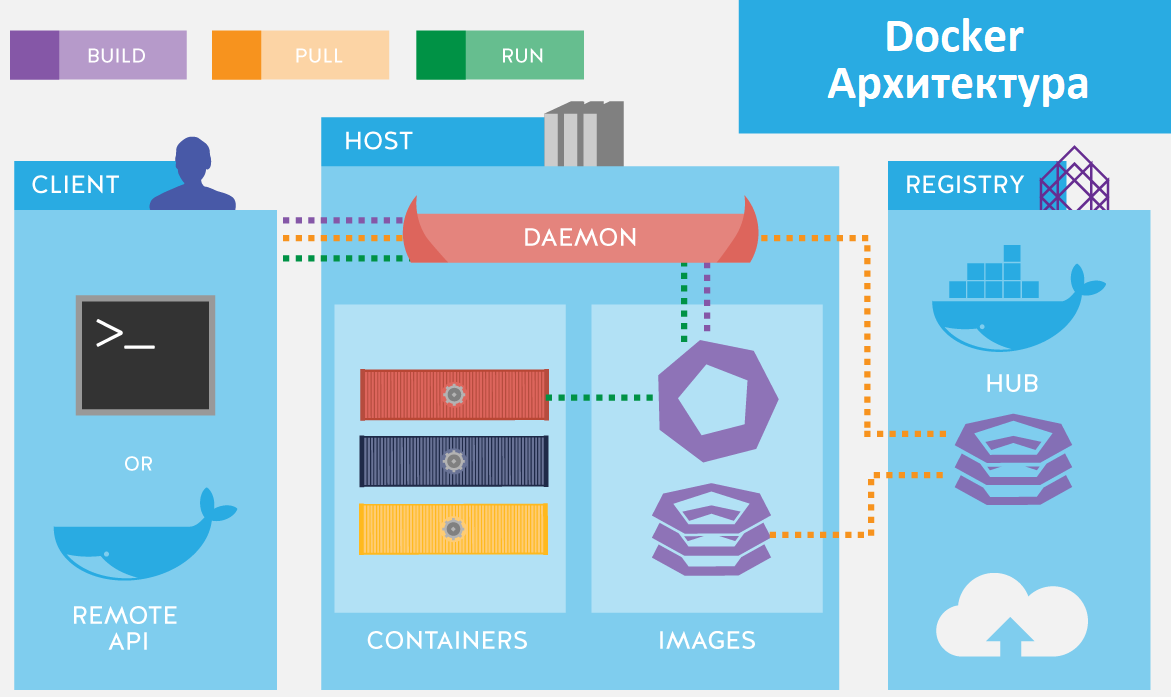

### Интуиция
Одна и та же инструкция может по-разному работать на разных компьютерах. Причины обычно связаны с различиями в операционной системе, версии Python, установленных пакетах, настройках терминала, правах доступа и уже установленном программном обеспечении.

Представьте если бы на семинаре каждый устанавливал все инструменты на свой компьютер, значительная часть времени ушла бы исправление разных ошибок и настройку подходящей среды

Как раз поэтому мы используем готовые рабочие среды (Google Colab, GitHub Codespaces). Таким образом мы работаем в предсказуемом окружении с заранее подготовленными зависимостями и сосредотачиваемся на непосредственном содержании.


![image.png](attachment:image.png)

**Docker решает близкую задачу** в инженерной практике: он позволяет **запускать приложение в стандартизированном и воспроизводимом окружении**, независимо от особенностей конкретной машины.

## Как работают с Docker

С Docker часто работают двумя способами.

Первый способ — через **Docker Desktop**. Это графическое приложение, которое позволяет запускать Docker на локальном компьютере, просматривать контейнеры, образы, тома и журналы, а также выполнять базовые операции через интерфейс. Такой формат удобен для первого знакомства и для визуального контроля состояния среды.

Второй способ — через **командную строку**. В этом случае управление Docker выполняется с помощью CLI-команд. Такой подход более универсален: он хорошо подходит для серверов, удаленных машин, автоматизации, CI/CD-пайплайнов и воспроизводимых инструкций. Кроме того, работа через CLI лучше показывает, какие именно действия выполняются и в какой последовательности.

В рамках семинара используется второй способ — работа через CLI.

![image.png](attachment:image.png)

При работе с Docker команды вводятся в терминале так же, как и другие знакомые команды, например `python ...` или `git ...`.

Команда `docker` — это обычная CLI-точка входа в инструмент. После нее указывается подкоманда и параметры, определяющие нужное действие.

На концептуальном уровне Docker работает с набором файлов, инструкций и артефактов, по которым компьютер создает и запускает изолированную среду по заданным правилам.

> *Ячейки ниже просто пример, они в тетрадке скорее всего не запустятся*

In [ ]:
docker --help

In [ ]:
docker version

In [ ]:
docker ps

## Github Codespaces

Мы уже знакомы с Google Colab, облачной средой выполнения, ориентированной прежде всего на работу с Python и ноутбуками. По сути, пользователь получает готовое окружение с интерпретатором Python, доступом к вычислениям и интерфейсом, работающим поверх удаленной Linux-машины.

GitHub Codespaces решает похожую задачу, но в более общем и приближенном к реальной разработке формате. Это облачная среда разработки, которая предоставляет полноценное рабочее пространство с файловой структурой проекта, терминалом, редактором, зависимостями и настройками окружения.

**Что важно в контексте семинара:**

- **Это не только ноутбук.** Codespaces предоставляет полноценную среду разработчика, в которой можно работать с файлами, директориями, терминалом и конфигурацией проекта.
- **Среда ближе к реальной инженерной практике.** Такой формат больше похож на обычную работу с репозиторием, исходным кодом и командной строкой.
- **Состояние проекта сохраняется в рабочем пространстве.** Файлы, структура директорий и настройки среды организованы как в обычной среде разработки.
- **Удобно для воспроизводимого старта.** Все участники могут начинать работу в близких условиях без длительной ручной настройки локального компьютера.

В рамках семинара GitHub Codespaces используется как пример готовой удаленной среды, в которой удобно изучать Docker и выполнять команды через CLI в более стандартном формате разработки.

**Единственный минус**: это не все время бесплатно!


![image.png](attachment:image.png)

> *Выходим из Google Colab и перемещаемся в эту же тетрадку, но только через Github Codespaces*

### Первый вариант (возможно будет сильно лагать)

* Заходим https://github.com/features/codespaces
   
![telegram-cloud-photo-size-2-5231110514463677194-y.jpg](attachment:telegram-cloud-photo-size-2-5231110514463677194-y.jpg)

* Логинимся

* Семинарист: открывает среду через репозиторий
  
![telegram-cloud-photo-size-2-5231110514463677198-y.jpg](attachment:telegram-cloud-photo-size-2-5231110514463677198-y.jpg)

* Студент: открывает чистую среду

![telegram-cloud-photo-size-2-5231110514463677195-y.jpg](attachment:telegram-cloud-photo-size-2-5231110514463677195-y.jpg)

### Второй вариант (более предпочтительный)

1) Заходим в VS code на своем компьютере
2) По инструкции скачиваем расширения "Remote Explorer" и "Github Codespaes"
3) Авторизуемся через Github Codespaces как показано на картинке и открываем либо новую среду, либо на основе репозитория

![telegram-cloud-photo-size-2-5231110514463677201-y.jpg](attachment:telegram-cloud-photo-size-2-5231110514463677201-y.jpg)

![telegram-cloud-photo-size-2-5231110514463677203-y.jpg](attachment:telegram-cloud-photo-size-2-5231110514463677203-y.jpg)

Вводим адрес репозитория, обычно <создатель>/<название>

![telegram-cloud-photo-size-2-5235553950189167274-y.jpg](attachment:telegram-cloud-photo-size-2-5235553950189167274-y.jpg)

Если открылось что-то вроде такой картинки, значит все получилось!

![telegram-cloud-document-2-5231110514003718541.jpg](attachment:telegram-cloud-document-2-5231110514003718541.jpg)

Побегаем по интерфейсу, создадим пару тестовых директорий через ползунок и протестируем пару команд в терминале...

**Вопрос**

Какой командой можно создать пустой файл?

**Вопрос**
Какой командой вывести все файлы в текущей директории? (в том числе скрытые)

# Основное содержаение

## Docker-образ

Docker-образ — это шаблон, по которому в дальнейшем создается и запускается контейнер.

Образ еще не является запущенным приложением. Это зафиксированное описание среды: какие файлы должны быть внутри, какая базовая система используется, какие зависимости установлены и какая команда должна быть выполнена при запуске.

Образ можно интерпретировать как инструкцию или заготовку для будущего окружения выполнения.

Важная особенность Docker-образа состоит в том, что он собирается послойно. Каждый слой фиксирует отдельное изменение, например выбор базового образа, копирование файлов проекта, установку пакетов или настройку рабочей директории. Такой подход упрощает повторное использование уже собранных частей и ускоряет повторные сборки.

Пока существует только образ, приложение еще не запущено. Запуск начинается тогда, когда на основе образа создается контейнер.

### Базовые команды для работы с образами

На первом этапе полезно разделить две операции:

- получить готовый образ из внешнего реестра
- посмотреть, какие образы доступны локально
- изучить метаданные и историю сборки образа

Ниже приведены базовые команды, относящиеся именно к образам.


> *Нижеперечисленные команды проделать в командной строке*

Получение готового образа `hello-world` из удаленного реестра Docker.

In [ ]:
docker pull hello-world

Просмотр списка Docker-образов, которые уже сохранены в локальной среде.

In [ ]:
docker images

Альтернативная форма команды для просмотра локальных образов через группу `docker image`.

In [ ]:
docker image ls

Просмотр подробных метаданных образа `hello-world`, включая конфигурацию, идентификаторы и параметры.

In [ ]:
docker image inspect hello-world

Просмотр истории слоев образа `hello-world`, из которых он был собран.

In [ ]:
docker history hello-world

### Другие полезные команды для работы с образами

- `docker search <image>` — поиск образов в удаленном реестре Docker Hub.
- `docker pull <image>` — загрузка образа из удаленного реестра в локальную среду.
- `docker images` — просмотр списка локально сохраненных образов.
- `docker image ls` — альтернативная форма просмотра списка локальных образов.
- `docker image inspect <image>` — просмотр подробных метаданных конкретного образа.
- `docker history <image>` — просмотр истории слоев образа.
- `docker image rm <image>` — удаление образа из локальной среды.
- `docker rmi <image>` — сокращенная форма удаления образа.
- `docker tag <source> <target>` — присвоение образу нового имени или тега.
- `docker image save -o file.tar <image>` — сохранение образа в tar-архив.
- `docker image load -i file.tar` — загрузка образа из tar-архива.
- `docker image prune` — удаление неиспользуемых образов.

## Docker-container

Docker-контейнер — это уже запущенный экземпляр образа.

Если образ — это шаблон и зафиксированное описание среды, то контейнер — это конкретный процесс, который создается и выполняется на основе этого шаблона. Именно контейнер запускается, работает, останавливается, перезапускается и удаляется.

Контейнер можно интерпретировать как практическую реализацию образа во время выполнения. На одном и том же образе можно создать несколько контейнеров, и каждый из них будет отдельным экземпляром с собственным состоянием времени выполнения.

Контейнеры позволяют запускать приложение в изолированной среде, не смешивая его зависимости и настройки с остальной системой.

### Жизненный цикл контейнера

Контейнер обычно проходит несколько основных состояний:

- **создан** — контейнер уже существует, но его основной процесс еще не запущен
- **запущен** — основной процесс контейнера выполняется
- **остановлен** — контейнер создан, но в данный момент не работает
- **удален** — контейнер полностью удален из локальной среды

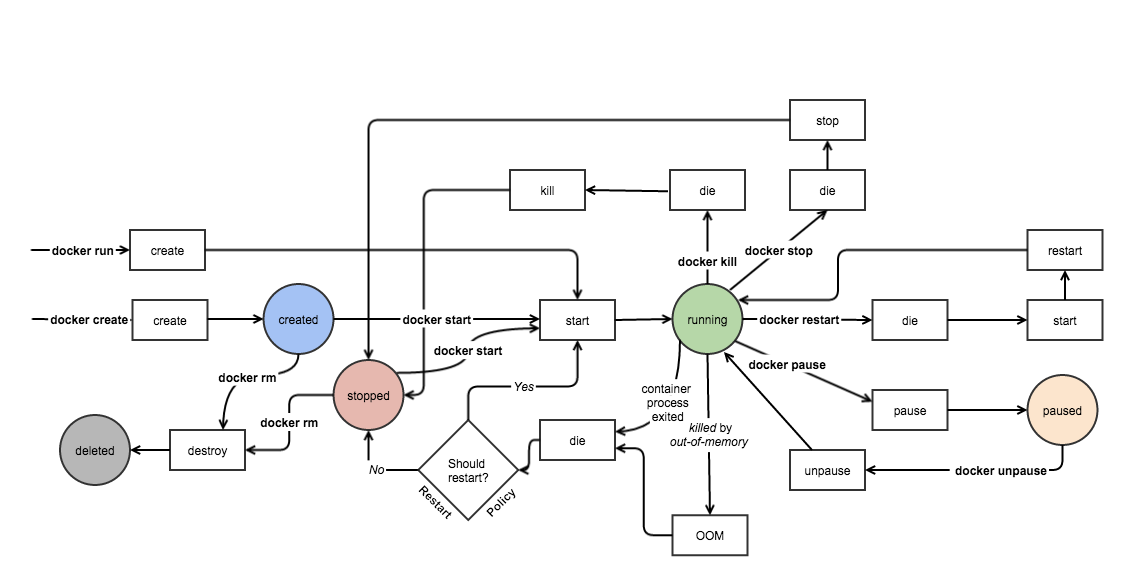

### Базовые команды с контейнерами

- запустить контейнер из готового образа
- посмотреть список контейнеров
- посмотреть, какие контейнеры работают прямо сейчас
- остановить контейнер
- удалить контейнер

Запуск контейнера из образа `hello-world`

In [ ]:
docker run hello-world

Просмотр только запущенных контейнеров

In [ ]:
docker ps

Просмотр всех контейнеров, включая остановленные.

In [ ]:
docker ps -a

```
Заметим, что после запуска от образа hello-world, контейнер исполнил заданную ему инструкцию и сразу остановился. Внутри него выполняется очень короткая программа: она выводит сообщение и после этого основной процесс завершается.

Для Docker это означает, что работа контейнера окончена. Контейнер существует, но уже находится в остановленном состоянии.

Это нормальное поведение. В Docker есть контейнеры, которые выполняют короткую задачу и завершаются, а есть контейнеры, которые запускают долгоживущий процесс и продолжают работать дальше.
```

Пример из долгоживущих - **nginx** - популярный веб-сервер. Его удобно использовать в учебных примерах, потому что он запускает долгоживущий серверный процесс внутри контейнера.

Если основной процесс внутри контейнера продолжает работать, контейнер тоже остается активным.


без `pull`, docker автоматически подтянет образ
флаг `-d` запускает контейнер в фоновом режиме, можно попробовать запустить без него и увидеть,
как вас сразу перекинет на веб сервер в контейнере, чтобы выйти из него `Control + c` или `Control + d`

In [ ]:
docker run -d nginx

In [ ]:
# теперь снова проверим
docker ps

Остановка работающего контейнера по его идентификатору или имени.

In [ ]:
docker stop <container_id> # остановим контейнер от nginx

Удаление остановленного контейнера по его идентификатору или имени.

In [ ]:
docker rm <container_id> # удалим контейнер от nginx

После запуска контейнера с долгоживущим процессом в него можно отдельно зайти и посмотреть, как устроена среда изнутри.

Для этого используется команда `docker exec`. Она позволяет выполнить новую команду внутри уже работающего контейнера.

В качестве простого примера удобно использовать образ `ubuntu`, потому что он близок к привычной Linux-среде и хорошо подходит для первых экспериментов с командной строкой внутри контейнера.

- `docker run` — создать и запустить контейнер
- `-d` — запустить контейнер в фоновом режиме
- `--name my_ubuntu` — назначить контейнеру имя `my_ubuntu`
- `ubuntu` — использовать образ `ubuntu`
- `sleep infinity` — удерживать контейнер в активном состоянии за счет долгоживущего процесса

In [ ]:
docker run -d --name my_ubuntu ubuntu sleep infinity

- `docker exec` — выполнить команду внутри уже работающего контейнера
- `-i` — сохранить интерактивный ввод
- `-t` — выделить терминал для работы в консоли
- `my_ubuntu` — имя контейнера
- `bash` — команда, которая запускает оболочку внутри контейнера

In [ ]:
docker exec -it my_ubuntu bash # после этого попадете в контейнер где можно протестировать уже знакомые команды

### Другие полезные команды для работы с контейнерами:

- `docker run <image>` — создать и сразу запустить контейнер из указанного образа.
- `docker run -d <image>` — запустить контейнер в фоне. Флаг `-d` означает **detached**.
- `docker run -it <image> bash` — запустить контейнер в интерактивном режиме с терминалом. Флаг `-i` означает **interactive**, флаг `-t` — **terminal**.
- `docker run --name <name> <image>` — запустить контейнер и сразу присвоить ему имя.
- `docker run --rm <image>` — автоматически удалить контейнер после завершения его работы.
- `docker ps` — показать только работающие контейнеры.
- `docker ps -a` — показать все контейнеры, включая остановленные. Флаг `-a` означает **all**.
- `docker stop <container>` — остановить контейнер.
- `docker start <container>` — запустить ранее остановленный контейнер.
- `docker restart <container>` — перезапустить контейнер.
- `docker rm <container>` — удалить остановленный контейнер.
- `docker logs <container>` — посмотреть логи контейнера.
- `docker logs -f <container>` — смотреть логи в реальном времени. Флаг `-f` означает **follow**.
- `docker exec -it <container> bash` — зайти внутрь уже работающего контейнера через интерактивную оболочку.
- `docker inspect <container>` — посмотреть подробные метаданные контейнера.
- `docker container ls` — альтернативная форма команды для просмотра контейнеров.
- `docker container prune` — удалить все остановленные контейнеры.


### Упражнение!!!

1. Выбрать новый образ `httpd`.
2. Проверить, есть ли этот образ в локальной среде.
3. Если образ отсутствует, загрузить его.
4. Запустить контейнер из образа `httpd` в фоновом режиме.
5. Убедиться, что контейнер находится в состоянии `Up`.
6. Самостоятельно остановить контейнер.
7. Проверить, что контейнер перешел в остановленное состояние.

#### решение

In [ ]:
docker images
docker pull httpd
docker run -d --name first_container httpd
docker ps
docker stop first_container
docker ps -a

## Добавление авторской бизнес-логики.

До этого этапа использовались готовые образы и готовые контейнеры, но в реальной практике этого недостаточно.

Обычно требуется запускать не чужой готовый сервис, а собственный проект: добавлять код, зависимости, свои файлы конфигурации и правила запуска приложения.

### Dockerbuild и Dockerfile

`docker build` — это команда сборки собственного Docker-образа.

Во время такой сборки Docker читает специальный файл `Dockerfile`, в котором пошагово описано, как должен быть устроен образ: какой базовый образ взять, какие файлы скопировать, какие зависимости установить, какую рабочую директорию задать и какую команду выполнять при запуске.

`Dockerfile` можно интерпретировать как рецепт сборки образа.

Каждая инструкция в `Dockerfile` в общем случае добавляет новое изменение в образ. На концептуальном уровне это удобно воспринимать как последовательное наращивание слоев: сначала берется базовая среда, затем поверх нее добавляются новые файлы, пакеты, настройки и команды.

Именно поэтому порядок строк в `Dockerfile` важен: он влияет не только на итоговую структуру образа, но и на повторное использование слоев при последующих сборках.

![image.png](attachment:image.png)

#### Основные команды docker build

- `docker build .` — собрать образ по `Dockerfile` из текущей директории.
- `docker build -t my_image .` — собрать образ и присвоить ему имя `my_image`. Флаг `-t` означает **tag**.
- `docker build -t my_image:1.0 .` — собрать образ и сразу задать имя и тег.
- `docker build -f Dockerfile.dev -t my_image .` — использовать для сборки не стандартный `Dockerfile`, а указанный файл. Флаг `-f` означает **file**.
- `docker build --no-cache -t my_image .` — собрать образ без использования кэша слоев.
- `docker build --pull -t my_image .` — перед сборкой попытаться обновить базовый образ.
- `docker build -q .` — вывести только итоговый идентификатор собранного образа. Флаг `-q` означает **quiet**.
- `docker build . - < Dockerfile` — собрать образ, если `Dockerfile` передается через стандартный ввод.


#### Основные инструкции в Dockerfile

- `FROM <image>` — указать базовый образ, с которого начинается сборка.
- `WORKDIR /app` — задать рабочую директорию внутри образа.
- `COPY . /app` — скопировать файлы из локальной директории внутрь образа.
- `ADD <src> <dst>` — добавить файлы в образ; используется реже, чем `COPY`, так как имеет дополнительное поведение.
- `RUN <command>` — выполнить команду во время сборки образа, например установку пакетов.
- `CMD ["python", "main.py"]` — задать команду по умолчанию, которая выполнится при запуске контейнера.
- `ENTRYPOINT ["python"]` — задать основной исполняемый процесс контейнера.
- `EXPOSE 8000` — декларативно указать, что приложение внутри контейнера использует определенный порт.
- `ENV KEY=value` — задать переменную окружения внутри образа.
- `ARG NAME=value` — задать аргумент сборки, доступный во время `docker build`.
- `USER appuser` — указать пользователя, от имени которого будут выполняться последующие команды.
- `LABEL key=value` — добавить метаданные к образу.

Давайте напишем простую програмум в контейнере, которая принимает список чисел и выводит минимум, максимум и среднее значение.

Для начала напишем функцию и проверим что она работает корректно:

In [ ]:
def min_max_mean(numbers):
    return min(numbers), max(numbers), sum(numbers) / len(numbers)

print(min_max_mean([1, 2, 3, 4, 5]))

(1, 5, 3.0)


Теперь нужно перенести ее в отдельный `.py` файл, который будет запускаться как самостоятельная программа.

Для этого используется прием `if __name__ == "__main__"`. Это стандартный Python-паттерн, который позволяет разделить код на две части:

- **определение функций** — они могут быть импортированы из другого модуля
- **точка входа** — блок кода, который выполняется только при прямом запуске файла через `python stats.py`

Когда Python запускает файл напрямую, переменная `__name__` принимает значение `"__main__"`. Если файл импортируется как модуль, `__name__` будет равно имени модуля, и блок `main` не выполнится.

In [ ]:
# stats.py
import sys

def min_max_mean(numbers):
    return min(numbers), max(numbers), sum(numbers) / len(numbers)


if __name__ == "__main__":
    numbers = [float(x) for x in sys.argv[1:]]
    mn, mx, mean = min_max_mean(numbers)
    print(f"min: {mn}")
    print(f"max: {mx}")
    print(f"mean: {mean}")

Для чтения аргументов командной строки используется модуль `sys`. При запуске `python stats.py 15 3 42` список `sys.argv` будет содержать:

- `sys.argv[0]` — имя файла (`stats.py`)
- `sys.argv[1:]` — все переданные аргументы (`['15', '3', '42']`)

Аргументы приходят как строки, поэтому их нужно преобразовать в числа через `float()` или `int()`.

Перенесем код уже в директорию first_programm и назовем stat.py

Запустим через командную строку

In [ ]:
python first_programm/stats.py 15 3 42 8 27 11 36 # возможно надо будет запустить python, а не python3, или вообще его перед этим скачать

После того, как мы убедились, что написали рабочий код, давайте создадим контейнер, в котором будет выполняться программа

In [ ]:
# first_programm/Dockerfile
FROM python:3.12-slim
COPY stats.py /stats.py
ENTRYPOINT ["python", "/stats.py"]

- `FROM python:3.12-slim` — базовый образ с установленным Python. Суффикс `slim` означает облегченную версию без лишних системных пакетов.
- `COPY stats.py /stats.py` — скопировать локальный файл `stats.py` внутрь образа по пути `/stats.py`.
- `ENTRYPOINT ["python", "/stats.py"]` — задать основную команду, которая будет выполняться при каждом запуске

Собираем образ. Флаг `-t` задает имя образа.

Точка в конце команды — это **контекст сборки**: директория, которую Docker передаёт демону (основному процессу, управляющему ключевыми компонентами Docker) для выполнения инструкций `Dockerfile`. Именно из этой директории берутся файлы при выполнении `COPY`. Контекст сборки обязательно должен содержать `Dockerfile` (если не указан явный путь через флаг `-f`). В нашем случае точка означает текущую директорию, где лежат и `Dockerfile`, и `stats.py`.

In [ ]:
docker build -t stats-app .

Проверяем

In [ ]:
docker images

Запускаем контейнер и передаем числа как аргументы командной строки. Аргументы после имени образа передаются в `ENTRYPOINT`.

In [ ]:
docker run stats-app 15 3 42 8 27 11 36

Можно зайти внутрь контейнера и вручную выполнять команды — например, чтобы отладить окружение или проверить, какие файлы там лежат. Для этого запускаем контейнер в интерактивном режиме и переопределяем точку входа на `bash`:

- `--entrypoint bash` — переопределяет `ENTRYPOINT` из `Dockerfile`, запуская вместо него `bash`.

In [ ]:
docker run -it --entrypoint bash stats-app

Запускаем внутри контейнера

In [ ]:
python /stats.py 15 3 42 # "Control + D" - выйти из контейнера

#### Задание: конвертер температур

Запустите контейнер с программой `temp.py`, которая принимает температуру в градусах Цельсия и выводит её в Фаренгейтах и Кельвинах. Весь контекст задавайте через директорию temperature_converter.

#### Решение

In [ ]:
mkdir temperature_converter

In [ ]:
import sys

def convert(celsius):
    fahrenheit = celsius * 9 / 5 + 32
    kelvin = celsius + 273.15
    return fahrenheit, kelvin

if __name__ == "__main__":
    celsius = float(sys.argv[1:])

    fahrenheit, kelvin = convert(celsius)

    print(f"fahrenheit: {fahrenheit}")
    print(f"kelvin: {kelvin}")

In [ ]:
# temperature_converter/Dockerfile
FROM python:3.12-slim
COPY temp.py /temp.py
ENTRYPOINT ["python", "/temp.py"]

In [ ]:
docker build -t temp-app .

In [ ]:
docker run temp-app 36.6